# Feature Selection Method Comparison

Each section covers one model. Within each section the same train/test split is used to rank features by four methods — SHAP, Gain, LIME, and Information Gain — then evaluates top-k (k = 1…10) features and plots a per-metric comparison.

## Setup

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison


In [53]:
for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")

Modules reloaded.


### Data

In [54]:
seed = 123
os.makedirs(f"figures/fraud_{seed}", exist_ok=True)

In [55]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/creditcard.csv")

Path to dataset files: /home/francesx/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [56]:
X = df.drop(columns=['Class'])
y = df['Class']

# Amount and Time are raw features (unlike V1-V28 which are already PCA-transformed).
# Log-scaling Amount reduces the long right tail; Time is cyclic so we keep as-is but scale.
X = X.copy()
X['Amount'] = np.log1p(X['Amount'])
X['Time'] = (X['Time'] - X['Time'].mean()) / X['Time'].std()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (227845, 30), Test: (56962, 30)


In [57]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# Step 1: undersample class 0 so minority = 10% of majority
under = RandomUnderSampler(sampling_strategy=0.1, random_state=seed)
X_res, y_res = under.fit_resample(X_train, y_train)

# Step 2: SMOTE class 1 up to 1:1
over = SMOTE(sampling_strategy=1.0, random_state=seed)
X_train_smote, y_train_smote = over.fit_resample(X_res, y_res)
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = pd.Series(y_train_smote, name=y_train.name)
print(f"After undersample+SMOTE — Train: {X_train_smote.shape}")
print(f"Class distribution: {y_train_smote.value_counts().to_dict()}")

After undersample+SMOTE — Train: (7880, 30)
Class distribution: {0: 3940, 1: 3940}


### Model Wrappers

In [ ]:
lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'binary', 'metric': 'average_precision',
        'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31,
        'min_data_in_leaf': 20, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5,
        'verbose': -1, 'seed': seed, 'num_threads': 1,
    },
    num_boost_round=300,
)

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'eta': 0.05, 'max_depth': 6, 'subsample': 0.8,
        'colsample_bytree': 0.8, 'seed': seed,
    },
    num_boost_round=300,
)

rf_wrapper = create_model_wrapper(
    'sklearn', model_class=RandomForestClassifier,
    model_params={'n_estimators': 200, 'random_state': seed, 'max_depth': 20, 'min_samples_leaf': 5},
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={
        'random_seed': seed, 'learning_rate': 0.05, 'depth': 6,
        'eval_metric': 'Logloss', 'iterations': 300,
    },
)

gb_wrapper = create_model_wrapper(
    'sklearn', model_class=GradientBoostingClassifier,
    model_params={'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
                  'subsample': 0.8, 'random_state': seed},
    use_tree_explainer=True,
)

lr_wrapper = create_model_wrapper(
    'sklearn', model_class=LogisticRegression,
    model_params={'random_state': seed, 'max_iter': 1000, 'C': 1.0, 'solver': 'saga'},
    use_linear_explainer=True, use_tree_explainer=False,
)

MODELS = {
    'LightGBM':          lgb_wrapper,
    'XGBoost':           xgb_wrapper,
    'RandomForest':      rf_wrapper,
    'CatBoost':          cb_wrapper,
    'GradientBoosting':  gb_wrapper,
    'LogisticRegression': lr_wrapper,
}


### Helper Functions

In [8]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict_proba(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        p = wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, LightGBMWrapper):
        p = wrapper.model.predict(X)
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict_proba(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        task = 'binary'
        sv = w.compute_shap(X_tr, task=task)
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    X_arr = X_tr.values.astype(float)
    feat_names = X_tr.columns.tolist()
    def _pred(arr, _w=w):
        return _predict_proba(_w, pd.DataFrame(arr, columns=feat_names))
    explainer = LimeTabularExplainer(
        X_arr, feature_names=feat_names,
        class_names=['0', '1'], mode='classification', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[1]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


# def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
#     results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
#     for k in k_values:
#         feats = ranking_df['feature'].head(k).tolist()
#         try:
#             w = _clone_wrapper(wrapper, input_dim=k)
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 w.fit(X_tr[feats], y_tr)
#                 proba = _predict_proba(w, X_te[feats])
#             p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
#             y_pred = (p_pos >= 0.5).astype(int)
#             results['accuracy'].append(accuracy_score(y_te, y_pred))
#             results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
#             results['ap'].append(average_precision_score(y_te, p_pos))
#             results['auc'].append(roc_auc_score(y_te, p_pos))
#         except Exception as e:
#             for m in results:
#                 results[m].append(float('nan'))
#     return results

def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]  # fixed order

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                proba = _predict_proba(w, X_te[feats])
            p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
            y_pred = (p_pos >= 0.5).astype(int)
            results['accuracy'].append(accuracy_score(y_te, y_pred))
            results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
            results['ap'].append(average_precision_score(y_te, p_pos))
            results['auc'].append(roc_auc_score(y_te, p_pos))
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results


def plot_comparison(model_name, all_results, k_values=list(range(1, 11))):
    metric_keys   = ['accuracy', 'f1',       'ap',                'auc'    ]
    metric_titles = ['Accuracy', 'F1 Score', 'Average Precision', 'AUC-ROC']
    method_styles = {
        'SHAP': dict(color='steelblue',  linestyle='-',  marker='o'),
        'Gain': dict(color='darkorange', linestyle='--', marker='s'),
        'LIME': dict(color='green',      linestyle='-.', marker='^'),
        'IG':   dict(color='crimson',    linestyle=':',  marker='D'),
        'Robust': dict(color='purple',   linestyle='-',  marker='X'),
    }
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    for ax, key, title in zip(axes.flatten(), metric_keys, metric_titles):
        for method, res in all_results.items():
            if res is None:
                continue
            ax.plot(k_values, res[key], linewidth=1.8, markersize=5,
                    label=method, **method_styles.get(method, {}))
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('k (number of features)')
        ax.set_ylabel(title)
        ax.set_xticks(k_values)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f'{model_name} — Feature Selection Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"figures/fraud_{seed}/fraud_{model_name}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()


### Information Gain Ranking (computed once, model-agnostic)

In [9]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_classif(X_train_smote, y_train_smote, random_state=42)

ig_ranking = (
    pd.DataFrame({'feature': X_train_smote.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('Top-10 IG features:')
ig_ranking.head(10)


Computing Information Gain scores...
Top-10 IG features:


,feature,importance
0,V14,0.495433
1,V10,0.439400
2,V12,0.438167
3,V17,0.436308
4,V11,0.405028
5,V4,0.400073
6,V3,0.359254
7,V16,0.353043
8,V7,0.309200
9,V2,0.282462


---
## LightGBM

### LightGBM — SHAP

In [10]:
print('Computing SHAP ranking for LightGBM...')
lightgbm_shap = get_shap_ranking(MODELS['LightGBM'], X_train_smote, y_train_smote)
print('Top-10:')
lightgbm_shap.head(10)


Computing SHAP ranking for LightGBM...
Top-10:


,feature,importance
0,V14,26737.003941
1,V4,12142.501725
2,V12,9960.093558
3,V10,8844.267821
4,V17,6380.019687
5,V3,3715.240517
6,V18,2651.739167
7,V8,2575.890417
8,Amount,2530.324044
9,V11,2415.901202


### LightGBM — Gain

In [11]:
print('Computing Gain ranking for LightGBM...')
lightgbm_gain = get_gain_ranking(MODELS['LightGBM'], X_train_smote, y_train_smote)
if lightgbm_gain is not None:
    print('Top-10:')
    display(lightgbm_gain.head(10))
else:
    print('Gain not supported for LightGBM')


Computing Gain ranking for LightGBM...
Top-10:


,feature,importance
0,V14,40274.965161
1,V10,19788.986561
2,V4,6156.823784
3,V12,5742.317731
4,V17,1884.294416
5,V8,1637.974728
6,V3,1312.127147
7,V18,1173.245039
8,V11,1129.248612
9,Amount,1051.536586


### LightGBM — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [12]:
print('Computing LIME ranking for LightGBM...')
lightgbm_lime = get_lime_ranking(
    MODELS['LightGBM'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
lightgbm_lime.head(10)

Computing LIME ranking for LightGBM...
Top-10:


,feature,importance
0,V14,0.308535
1,V4,0.169764
2,V12,0.141503
3,V10,0.080571
4,V17,0.063064
5,V3,0.061078
6,V8,0.030286
7,Amount,0.028664
8,V11,0.028056
9,V9,0.027898


### LightGBM — Robust

In [13]:
lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,  # Use preprocessed data with one-hot encoded categoricals
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [02:00<00:00,  4.15it/s]


In [14]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [15]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

lightgbm_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
lightgbm_robust.head(10)


,feature,importance
Rank,,
1,V14,26032.678598
2,V4,13073.563496
3,V12,12620.407837
4,V10,9499.539796
5,V17,7130.869674
6,V3,4327.978604
7,V11,4094.746137
8,V1,3351.982490
9,V8,2930.734832


### LightGBM — Evaluation & Comparison

Evaluating LightGBM — SHAP...
Evaluating LightGBM — Gain...
Evaluating LightGBM — LIME...
Evaluating LightGBM — IG...
Evaluating LightGBM — Robust Bootstrap...


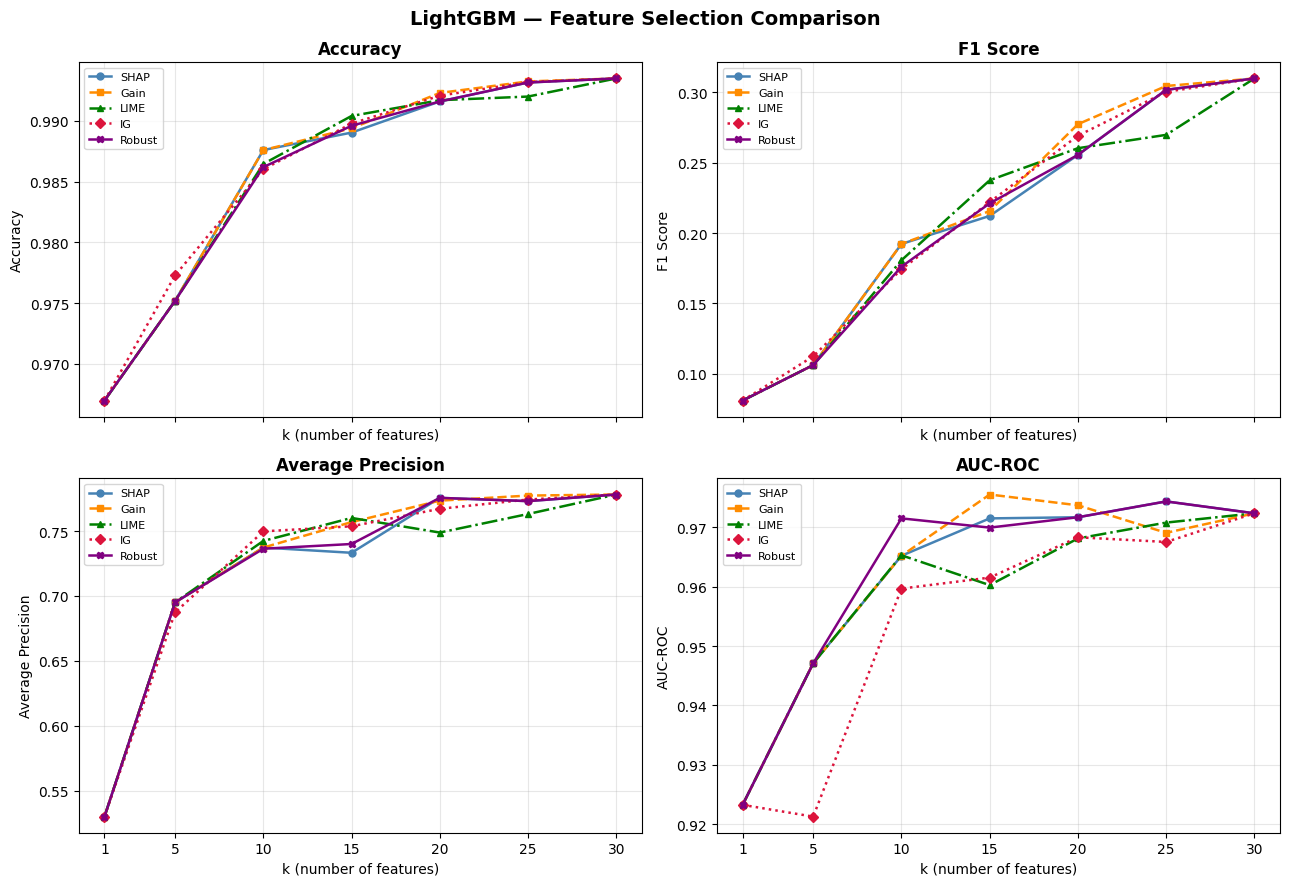

In [16]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating LightGBM — SHAP...')
lightgbm_res_shap = evaluate_topk(MODELS['LightGBM'], lightgbm_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LightGBM — Gain...')
lightgbm_res_gain = evaluate_topk(MODELS['LightGBM'], lightgbm_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if lightgbm_gain is not None else None

print('Evaluating LightGBM — LIME...')
lightgbm_res_lime = evaluate_topk(MODELS['LightGBM'], lightgbm_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LightGBM — IG...')
lightgbm_res_ig = evaluate_topk(MODELS['LightGBM'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LightGBM — Robust Bootstrap...')
lightgbm_res_robust = evaluate_topk(MODELS['LightGBM'], lightgbm_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'Robust': lightgbm_res_robust},
    k_values,
)


---
## XGBoost

### XGBoost — SHAP

In [17]:
print('Computing SHAP ranking for XGBoost...')
xgboost_shap = get_shap_ranking(MODELS['XGBoost'], X_train_smote, y_train_smote)
print('Top-10:')
xgboost_shap.head(10)


Computing SHAP ranking for XGBoost...
Top-10:


,feature,importance
0,V14,21494.564453
1,V4,9610.020508
2,V12,7807.650879
3,V10,6808.936523
4,V17,4785.656738
5,V8,3893.114258
6,V18,3231.974854
7,V3,2468.167969
8,Amount,2228.934326
9,Time,1970.520630


### XGBoost — Gain

In [18]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train_smote, y_train_smote)
if xgboost_gain is not None:
    print('Top-10:')
    display(xgboost_gain.head(10))
else:
    print('Gain not supported for XGBoost')


Computing Gain ranking for XGBoost...
Top-10:


,feature,importance
0,V14,125.545662
1,V10,41.201118
2,V12,17.826565
3,V4,13.120757
4,V8,7.897039
5,V17,7.412995
6,V11,5.720382
7,V1,5.440557
8,V3,4.943923
9,V7,4.621136


### XGBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [19]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
xgboost_lime.head(10)


Computing LIME ranking for XGBoost...
Top-10:


,feature,importance
0,V14,0.318021
1,V4,0.175018
2,V12,0.137592
3,V10,0.092837
4,V17,0.067789
5,V3,0.049821
6,V8,0.047292
7,Amount,0.033779
8,V23,0.030772
9,Time,0.026778


### XGBoost — Robust

In [20]:
xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=xgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 0/500 [00:00<?, ?it/s]

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [01:50<00:00,  4.52it/s]


In [21]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [22]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

xgboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
xgboost_robust.head(10)


,feature,importance
Rank,,
1,V14,19265.236083
2,V12,10927.233133
3,V4,9710.817354
4,V10,8065.455299
5,V17,4729.350894
6,V8,4562.135021
7,V18,3442.046411
8,Amount,2686.679800
9,V11,2656.754814


### XGBoost — Evaluation & Comparison

Evaluating XGBoost — SHAP...
Evaluating XGBoost — Gain...
Evaluating XGBoost — LIME...
Evaluating XGBoost — IG...
Evaluating XGBoost — Robust Bootstrap...


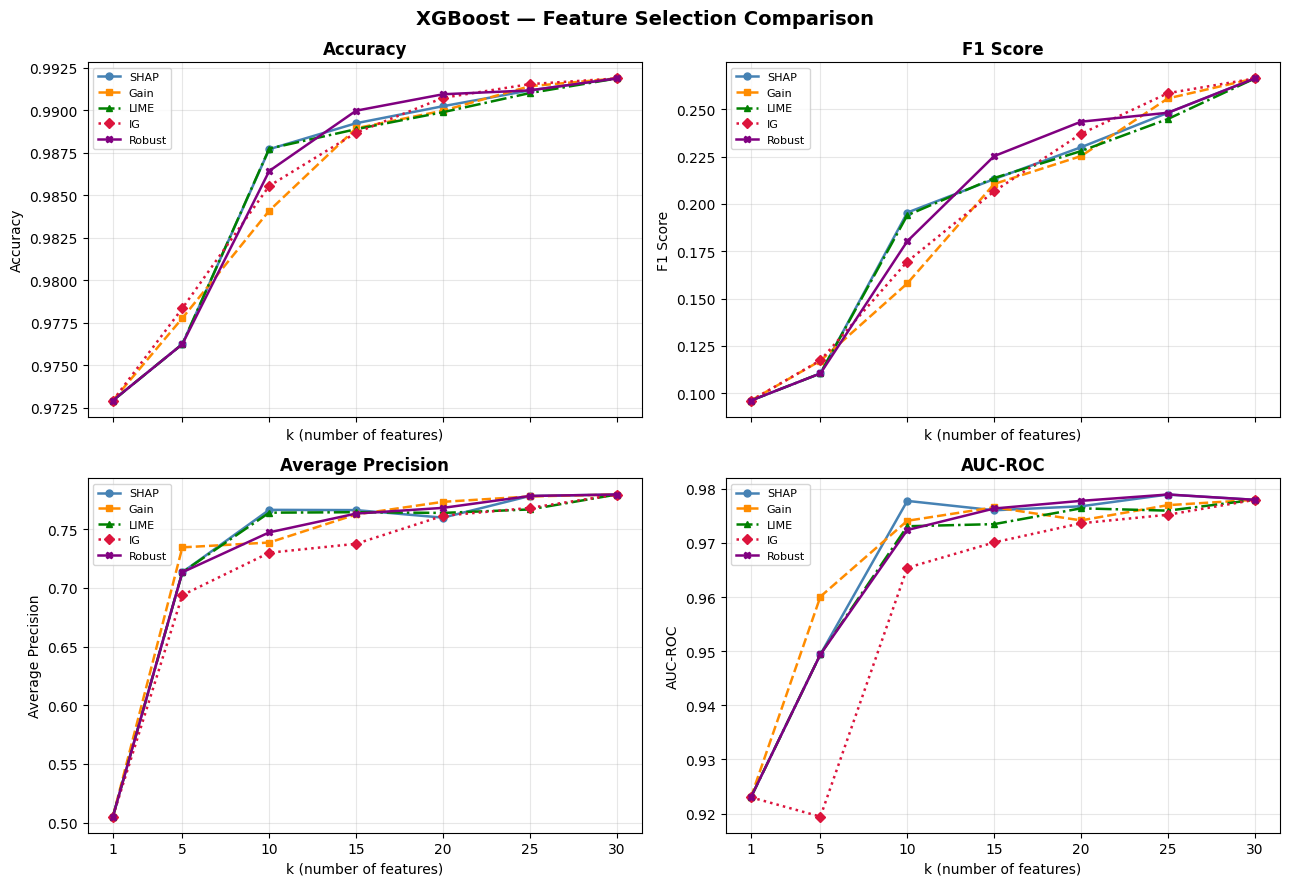

In [23]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating XGBoost — SHAP...')
xgboost_res_shap = evaluate_topk(MODELS['XGBoost'], xgboost_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating XGBoost — Gain...')
xgboost_res_gain = evaluate_topk(MODELS['XGBoost'], xgboost_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if xgboost_gain is not None else None

print('Evaluating XGBoost — LIME...')
xgboost_res_lime = evaluate_topk(MODELS['XGBoost'], xgboost_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating XGBoost — IG...')
xgboost_res_ig = evaluate_topk(MODELS['XGBoost'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating XGBoost — Robust Bootstrap...')
xgboost_res_robust = evaluate_topk(MODELS['XGBoost'], xgboost_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'XGBoost',
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain,
     'LIME': xgboost_res_lime, 'IG':   xgboost_res_ig, 'Robust': xgboost_res_robust},
    k_values,
)

---
## RandomForest

### RandomForest — SHAP

In [24]:
print('Computing SHAP ranking for RandomForest...')
randomforest_shap = get_shap_ranking(MODELS['RandomForest'], X_train_smote, y_train_smote)
print('Top-10:')
randomforest_shap.head(10)


Computing SHAP ranking for RandomForest...
Top-10:


,feature,importance
0,V14,907.710165
1,V12,582.503894
2,V10,485.024678
3,V4,428.796284
4,V17,377.730027
5,V11,347.754007
6,V3,250.351161
7,V16,128.952165
8,V7,113.719454
9,V8,83.702030


### RandomForest — Gain

In [25]:
print('Computing Gain ranking for RandomForest...')
randomforest_gain = get_gain_ranking(MODELS['RandomForest'], X_train_smote, y_train_smote)
if randomforest_gain is not None:
    print('Top-10:')
    display(randomforest_gain.head(10))
else:
    print('Gain not supported for RandomForest')


Computing Gain ranking for RandomForest...
Top-10:


,feature,importance
0,V14,0.212902
1,V10,0.131853
2,V12,0.118284
3,V11,0.097473
4,V17,0.091882
5,V4,0.069222
6,V3,0.056193
7,V16,0.037588
8,V7,0.032999
9,V9,0.016014


### RandomForest — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [26]:
print('Computing LIME ranking for RandomForest...')
randomforest_lime = get_lime_ranking(
    MODELS['RandomForest'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
randomforest_lime.head(10)

Computing LIME ranking for RandomForest...
Top-10:


,feature,importance
0,V14,0.144567
1,V12,0.101429
2,V4,0.080864
3,V17,0.071360
4,V10,0.059887
5,V3,0.053119
6,V11,0.034345
7,V16,0.022603
8,V8,0.013277
9,V7,0.012344


### RandomForest — Robust

In [27]:
rf_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1,
    zero_tol=0,
    model_wrapper=rf_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [39:02<00:00,  4.69s/it] 


In [28]:
rf_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=rf_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [29]:
tmp = rf_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

rf_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
rf_robust.head(10)


,feature,importance
Rank,,
1,V14,802.166840
2,V12,579.312771
3,V10,493.334616
4,V4,453.638763
5,V17,367.179131
6,V11,338.587271
7,V3,226.644264
8,V16,199.160468
9,V7,129.722030


### RandomForest — Evaluation & Comparison

Evaluating RandomForest — SHAP...
Evaluating RandomForest — Gain...
Evaluating RandomForest — LIME...
Evaluating RandomForest — IG...
Evaluating RandomForest — Robust Bootstrap...


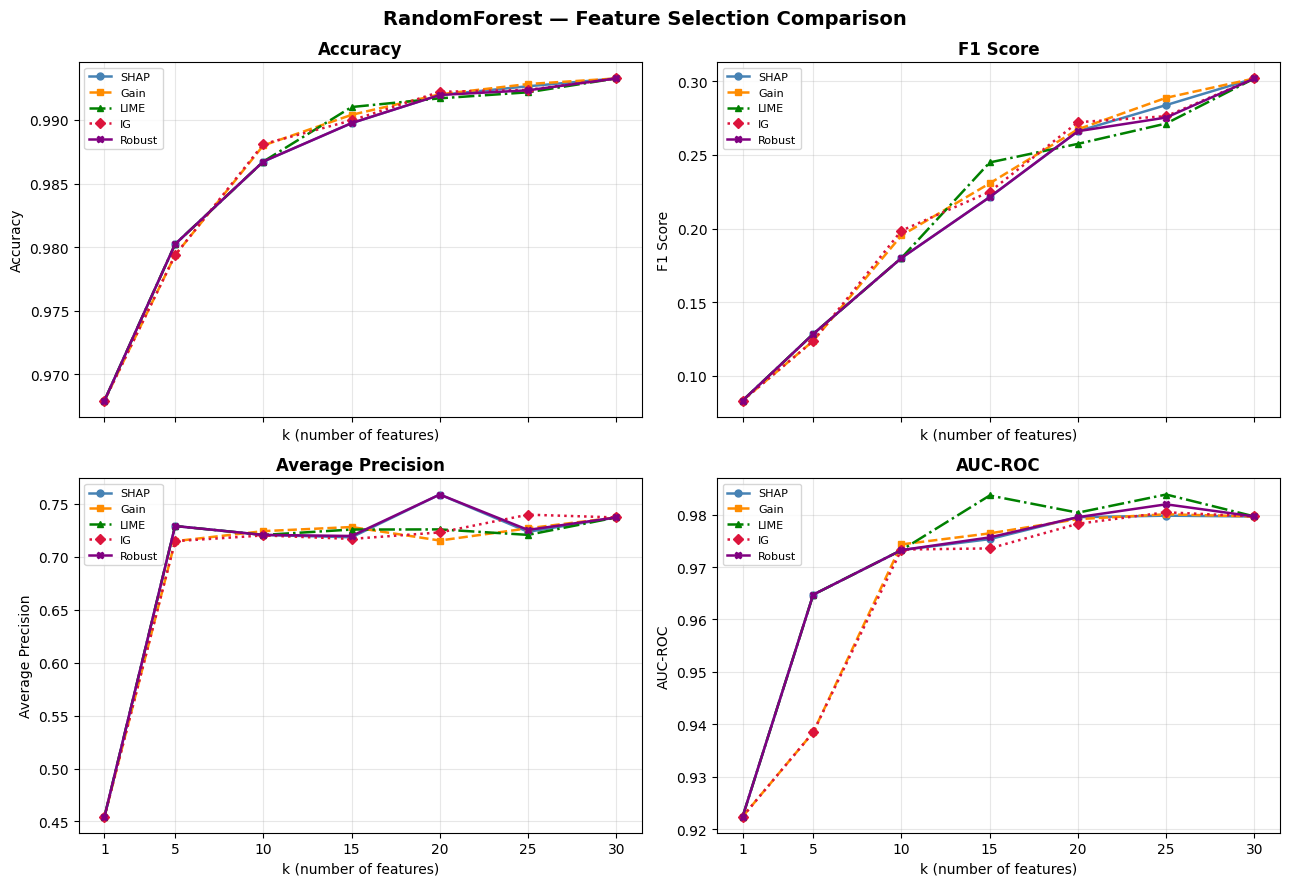

In [30]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating RandomForest — SHAP...')
randomforest_res_shap = evaluate_topk(MODELS['RandomForest'], randomforest_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating RandomForest — Gain...')
randomforest_res_gain = evaluate_topk(MODELS['RandomForest'], randomforest_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if randomforest_gain is not None else None

print('Evaluating RandomForest — LIME...')
randomforest_res_lime = evaluate_topk(MODELS['RandomForest'], randomforest_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating RandomForest — IG...')
randomforest_res_ig = evaluate_topk(MODELS['RandomForest'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating RandomForest — Robust Bootstrap...')
randomforest_res_robust = evaluate_topk(MODELS['RandomForest'], rf_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'Gain': randomforest_res_gain,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'Robust': randomforest_res_robust},
    k_values,
)


---
## CatBoost

### CatBoost — SHAP

In [31]:
print('Computing SHAP ranking for CatBoost...')
catboost_shap = get_shap_ranking(MODELS['CatBoost'], X_train_smote, y_train_smote)
print('Top-10:')
catboost_shap.head(10)

Computing SHAP ranking for CatBoost...
Top-10:


,feature,importance
0,V14,14856.487859
1,V4,9289.279038
2,V12,5035.114962
3,V17,3374.060968
4,V3,2263.160849
5,V11,2254.228301
6,V1,1726.233455
7,V10,1584.541678
8,V18,1217.188763
9,V8,1163.002055


### CatBoost — Gain

In [32]:
print('Computing Gain ranking for CatBoost...')
catboost_gain = get_gain_ranking(MODELS['CatBoost'], X_train_smote, y_train_smote)
if catboost_gain is not None:
    print('Top-10:')
    display(catboost_gain.head(10))
else:
    print('Gain not supported for CatBoost')


Computing Gain ranking for CatBoost...
Top-10:


,feature,importance
0,V14,17.293094
1,V4,15.343737
2,V12,7.510958
3,V17,5.784289
4,V8,5.174122
5,V11,4.886735
6,V1,4.684651
7,V18,4.580315
8,V3,3.650393
9,V5,2.891518


### CatBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [33]:
print('Computing LIME ranking for CatBoost...')
catboost_lime = get_lime_ranking(
    MODELS['CatBoost'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
catboost_lime.head(10)


Computing LIME ranking for CatBoost...
Top-10:


,feature,importance
0,V14,0.311268
1,V4,0.168470
2,V12,0.080423
3,V17,0.056767
4,V3,0.046168
5,V8,0.042859
6,V10,0.033482
7,V11,0.027655
8,V9,0.018567
9,V1,0.017118


### CatBoost — Robust

In [34]:
cb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=cb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [07:53<00:00,  1.06it/s]


In [35]:
cb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [36]:
tmp = cb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

catboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
catboost_robust.head(10)


,feature,importance
Rank,,
1,V14,12886.446654
2,V4,10262.596875
3,V12,7465.367887
4,V11,2408.669345
5,V1,2196.216098
6,V3,2096.599166
7,V10,1854.492847
8,V17,1492.400005
9,V18,1443.412429


### CatBoost — Evaluation & Comparison

Evaluating CatBoost — SHAP...
Evaluating CatBoost — Gain...
Evaluating CatBoost — LIME...
Evaluating CatBoost — IG...
Evaluating CatBoost — Robust Bootstrap...


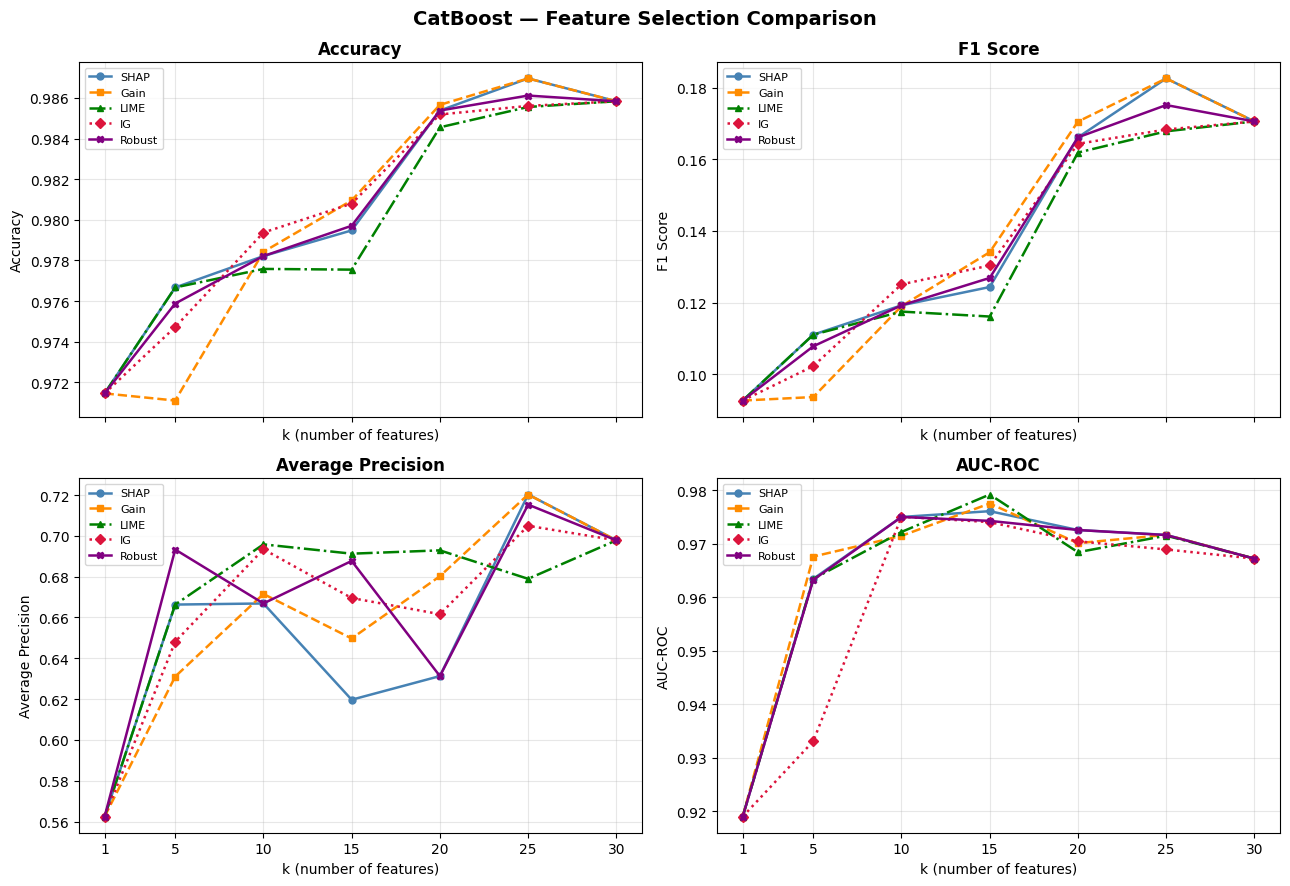

In [37]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating CatBoost — SHAP...')
catboost_res_shap = evaluate_topk(MODELS['CatBoost'], catboost_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating CatBoost — Gain...')
catboost_res_gain = evaluate_topk(MODELS['CatBoost'], catboost_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if catboost_gain is not None else None

print('Evaluating CatBoost — LIME...')
catboost_res_lime = evaluate_topk(MODELS['CatBoost'], catboost_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating CatBoost — IG...')
catboost_res_ig = evaluate_topk(MODELS['CatBoost'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating CatBoost — Robust Bootstrap...')
catboost_res_robust = evaluate_topk(MODELS['CatBoost'], catboost_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Gain': catboost_res_gain,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'Robust': catboost_res_robust},
    k_values,
)


---
## GradientBoosting

### GradientBoosting — SHAP

In [38]:
print('Computing SHAP ranking for GradientBoosting...')
gradientboosting_shap = get_shap_ranking(MODELS['GradientBoosting'], X_train_smote, y_train_smote)
print('Top-10:')
gradientboosting_shap.head(10)

Computing SHAP ranking for GradientBoosting...
Top-10:


,feature,importance
0,V14,16538.704938
1,V4,8644.258579
2,V12,7540.911965
3,V11,3423.831668
4,V3,2284.409298
5,V10,1534.369156
6,V1,1525.683229
7,V18,1493.045889
8,V8,1458.137407
9,V17,908.662219


### GradientBoosting — Gain

In [39]:
print('Computing Gain ranking for GradientBoosting...')
gradientboosting_gain = get_gain_ranking(MODELS['GradientBoosting'], X_train_smote, y_train_smote)
if gradientboosting_gain is not None:
    print('Top-10:')
    display(gradientboosting_gain.head(10))
else:
    print('Gain not supported for GradientBoosting')


Computing Gain ranking for GradientBoosting...


Top-10:


,feature,importance
0,V14,0.768255
1,V4,0.071958
2,V12,0.037492
3,V8,0.013288
4,V3,0.012075
5,V7,0.010261
6,V1,0.007980
7,V11,0.007909
8,V17,0.007759
9,V10,0.007468


### GradientBoosting — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [40]:
print('Computing LIME ranking for GradientBoosting...')
gradientboosting_lime = get_lime_ranking(
    MODELS['GradientBoosting'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
gradientboosting_lime.head(10)

Computing LIME ranking for GradientBoosting...
Top-10:


,feature,importance
0,V14,0.222157
1,V4,0.221335
2,V12,0.131903
3,V3,0.076714
4,V11,0.046279
5,V10,0.043367
6,V8,0.037995
7,V17,0.026047
8,V18,0.025879
9,Time,0.018365


### GradientBoosting — Robust

In [41]:
gb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=gb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [1:10:05<00:00,  8.41s/it]


In [42]:
gb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=gb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [43]:
tmp = gb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

gradientboosting_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
gradientboosting_robust.head(10)


,feature,importance
Rank,,
1,V14,14435.030012
2,V12,8754.761474
3,V4,8663.126635
4,V11,3665.217660
5,V3,2435.457790
6,V1,1939.093867
7,V8,1712.105027
8,V18,1570.545689
9,V10,1090.146810


### GradientBoosting — Evaluation & Comparison

Evaluating GradientBoosting — SHAP...


Evaluating GradientBoosting — Gain...
Evaluating GradientBoosting — LIME...
Evaluating GradientBoosting — IG...
Evaluating GradientBoosting — Robust Bootstrap...


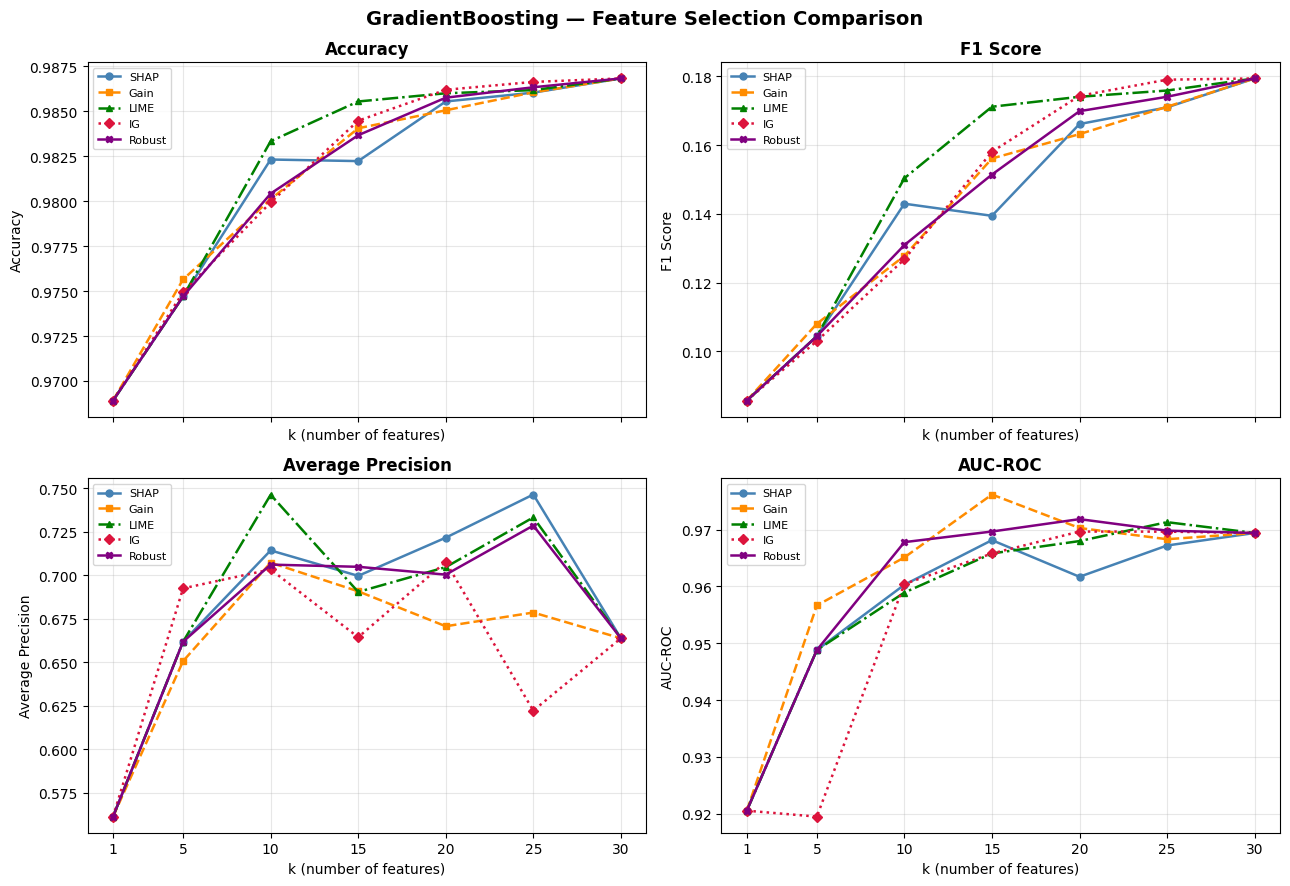

In [44]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating GradientBoosting — SHAP...')
gradientboosting_res_shap = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating GradientBoosting — Gain...')
gradientboosting_res_gain = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if gradientboosting_gain is not None else None

print('Evaluating GradientBoosting — LIME...')
gradientboosting_res_lime = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating GradientBoosting — IG...')
gradientboosting_res_ig = evaluate_topk(MODELS['GradientBoosting'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating GradientBoosting — Robust Bootstrap...')
gradientboosting_res_robust = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'Gain': gradientboosting_res_gain,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'Robust': gradientboosting_res_robust},
    k_values,
)


---
## LogisticRegression

### LogisticRegression — SHAP

In [45]:
print('Computing SHAP ranking for LogisticRegression...')
logisticregression_shap = get_shap_ranking(MODELS['LogisticRegression'], X_train_smote, y_train_smote)
print('Top-10:')
logisticregression_shap.head(10)

Computing SHAP ranking for LogisticRegression...
Top-10:


,feature,importance
0,V14,46700.236961
1,V10,31047.440331
2,V12,29766.465247
3,V17,25113.311030
4,V4,20584.470729
5,V1,10823.238645
6,V11,9898.473480
7,V9,8018.924127
8,V8,7114.746323
9,V7,5677.004743


### LogisticRegression — Gain

In [46]:
print('Computing Gain ranking for LogisticRegression...')
logisticregression_gain = get_gain_ranking(MODELS['LogisticRegression'], X_train_smote, y_train_smote)
if logisticregression_gain is not None:
    print('Top-10:')
    display(logisticregression_gain.head(10))
else:
    print('Gain not supported for LogisticRegression')


Computing Gain ranking for LogisticRegression...
Top-10:


,feature,importance
0,V14,1.540344
1,V10,1.186407
2,V12,1.075071
3,V4,1.022433
4,V28,0.821360
5,V17,0.715887
6,V9,0.608961
7,V11,0.580561
8,V22,0.541481
9,V20,0.516406


### LogisticRegression — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [47]:
print('Computing LIME ranking for LogisticRegression...')
logisticregression_lime = get_lime_ranking(
    MODELS['LogisticRegression'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
logisticregression_lime.head(10)


Computing LIME ranking for LogisticRegression...
Top-10:


,feature,importance
0,V14,0.124196
1,V17,0.089307
2,V12,0.076108
3,V4,0.072215
4,V10,0.071786
5,V1,0.059598
6,V9,0.041515
7,V8,0.034451
8,V11,0.032760
9,V5,0.025768


### LogisticRegression — Robust

In [48]:
lr_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lr_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 0/500 [00:00<?, ?it/s]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Bootstrap repeats (feature-agg):   0%|          | 1/500 [00:05<48:57,  5.89s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Bootstrap repeats (feature-agg):   1%|          | 3/500 [00:05<12:57,  1.56s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

In [49]:
lr_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lr_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [50]:
tmp = lr_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

logisticregression_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
logisticregression_robust.head(10)


,feature,importance
Rank,,
1,V14,46388.981048
2,V10,30161.144937
3,V12,27054.662373
4,V4,21163.327385
5,V17,14442.209528
6,V11,9267.589474
7,V9,7900.125100
8,V1,7612.031979
9,V8,6474.403145


### LogisticRegression — Evaluation & Comparison

Evaluating LogisticRegression — SHAP...
Evaluating LogisticRegression — Gain...


Evaluating LogisticRegression — LIME...
Evaluating LogisticRegression — IG...
Evaluating LogisticRegression — Robust Bootstrap...


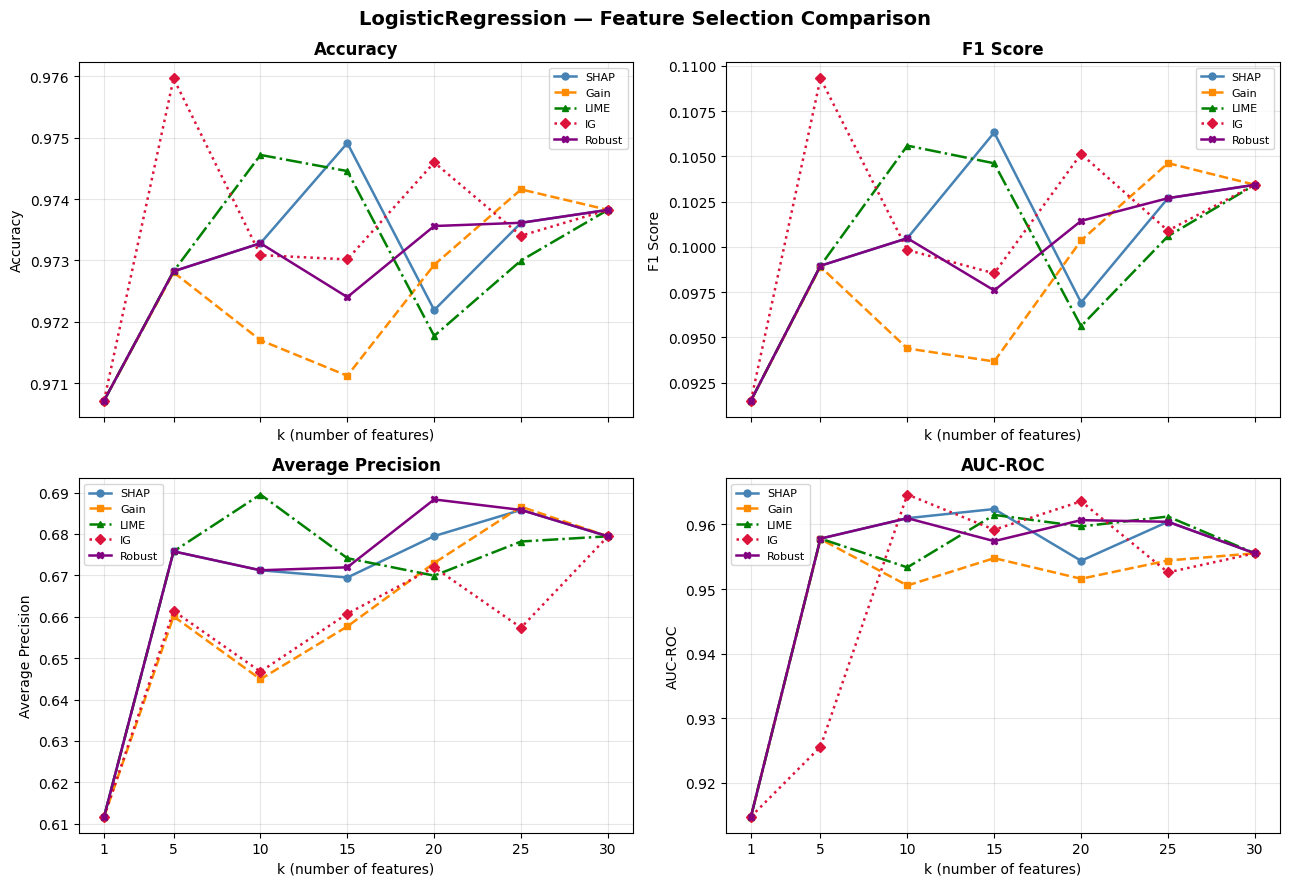

In [51]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating LogisticRegression — SHAP...')
logisticregression_res_shap = evaluate_topk(MODELS['LogisticRegression'], logisticregression_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LogisticRegression — Gain...')
logisticregression_res_gain = evaluate_topk(MODELS['LogisticRegression'], logisticregression_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if logisticregression_gain is not None else None

print('Evaluating LogisticRegression — LIME...')
logisticregression_res_lime = evaluate_topk(MODELS['LogisticRegression'], logisticregression_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LogisticRegression — IG...')
logisticregression_res_ig = evaluate_topk(MODELS['LogisticRegression'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LogisticRegression — Robust Bootstrap...')
logisticregression_res_robust = evaluate_topk(MODELS['LogisticRegression'], logisticregression_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'LogisticRegression',
    {'SHAP': logisticregression_res_shap, 'Gain': logisticregression_res_gain,
     'LIME': logisticregression_res_lime, 'IG':   logisticregression_res_ig, 'Robust': logisticregression_res_robust},
    k_values,
)
